# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [7]:
# Import warnings
# import warnings to suppress warning messages to maintain a clean and readable notebook while execution
import warnings
warnings.filterwarnings('ignore')


In [8]:
# Import the libraries you will be using for analysis
# installing below mentioned recommended versions of numpy and pandas library since current version do not match with recommended version
!pip install numpy==1.26.4
!pip install pandas==2.2.2


# import numpy for numerical computation
import numpy as np

# import pandas for data manipulation
import pandas as pd

# import matplot lib for basic data visualization
import matplotlib.pyplot as plt

# import seaborn for statistical visualization
import seaborn as sns


In [46]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [137]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')

#loading just one file to understand the structure,memory usage,size of the file
df = pd.read_parquet('/Users/deekshasrivastava/Downloads/AI_ML_MainCourse_Files/Datasets and Dictionary/trip_records/2023-1.parquet')

df.info()

#displaying the information of the file to understand the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [138]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
#updated the path to the path where the folder with all files is stored in my machine
os.chdir('/Users/deekshasrivastava/Downloads/AI_ML_MainCourse_Files/Datasets and Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        
        # Reading the current file
        #reading each month file one by one
        month_df = pd.read_parquet(file_path)
        
        #to create sample for each day and hour, extract the date and hour from tpep_pickup_datetime
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_time'] = month_df['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        #loop through each date of current month file
        for day in month_df['pickup_date'].unique():
            
            day_data = month_df[month_df['pickup_date'] == day]
            
            # Iterate through each hour of the selected date
            #loop through each hour of the day to get hour_data
            for hour in range(24):
                
                hour_data = day_data[day_data['pickup_time'] == hour]

                # Sample 5% of the hourly data randomly
                #getting 5% of the data available for each hour of each day
                sample = hour_data.sample(frac = 0.05, random_state = 42)

                # add data of this hour to the dataframe
                #append it to the existing sampled_data
                sampled_data = pd.concat([sampled_data, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [139]:
# Store the df in csv/parquet
# df.to_parquet('')
#check total number of rows in the the sample_data file
#len(df)

#since number of rows in the sample_data file is 1896400, reducing it to 300000
df = df.sample(n=300000, random_state=42)
len(df)

#storing the sample data in sample_data.parquet file
df.to_parquet('sample_data.parquet', index=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 2396581 to 1267952
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289737 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289737 non-null  float64       
 6   store_and_fwd_flag     289737 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  fl

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [140]:
# Load the new data file
#loading the sampled data
df = pd.read_parquet('/Users/deekshasrivastava/Downloads/AI_ML_MainCourse_Files/Datasets and Dictionary/trip_records/sample_data.parquet')


In [141]:
# df.head()
#checking first 5 rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_time,airport_fee
0,1,2023-09-28 09:13:40,2023-09-28 09:18:59,1.0,0.70,1.0,N,68,158,1,...,0.5,2.65,0.0,1.0,13.15,2.5,0.0,2023-09-28,9,NaN
1,2,2023-08-27 18:00:07,2023-08-27 18:13:13,1.0,2.47,1.0,N,142,236,1,...,0.5,3.92,0.0,1.0,23.52,2.5,0.0,2023-08-27,18,NaN
2,2,2023-08-05 21:26:26,2023-08-05 21:44:12,1.0,3.11,1.0,N,13,90,2,...,0.5,0.00,0.0,1.0,24.10,2.5,0.0,2023-08-05,21,NaN
3,1,2023-02-28 20:11:57,2023-02-28 20:27:28,1.0,2.50,1.0,N,236,164,1,...,0.5,4.00,0.0,1.0,23.90,2.5,0.0,2023-02-28,20,NaN
4,2,2023-10-19 00:00:32,2023-10-19 00:11:52,1.0,2.52,1.0,N,79,162,1,...,0.5,4.80,0.0,1.0,24.00,2.5,0.0,2023-10-19,0,NaN


In [142]:
# df.info()
#to check all information related to sample_data size, rows, columns, null columns etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289737 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289737 non-null  float64       
 6   store_and_fwd_flag     289737 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [143]:
# Fix the index and drop any columns that are not needed
#dropping previously created picku_date and pickup_time column as this data is already available in tpep_pickup_datetime column 
#and resetting the index

df = df.drop(columns = ['pickup_date','pickup_time'])
df = df.reset_index(drop = True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289737 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289737 non-null  float64       
 6   store_and_fwd_flag     289737 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [144]:
# Combine the two airport fee columns
#combining the data from airport_fee to Airport_fee column , then checking again the info for both columns 
#and then dropping extra airport_fee column
df['Airport_fee'] = df['Airport_fee'].fillna(df['airport_fee'])
df = df.drop(columns = ['airport_fee'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289737 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289737 non-null  float64       
 6   store_and_fwd_flag     289737 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [145]:
# check where values of fare amount are negative
#get all the monetary columns together
fare_col = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
            'total_amount', 'congestion_surcharge', 'Airport_fee']

#print all columns of all rows with negative monetary values
negative_col = df[(df[fare_col] < 0).any(axis = 1)]
print(negative_col)


        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
35445          2  2023-01-25 11:10:37   2023-01-25 11:11:02              1.0   
74673          2  2023-08-02 16:57:03   2023-08-02 17:15:42              1.0   
107295         2  2023-08-25 21:14:13   2023-08-25 21:19:14              1.0   
139468         2  2023-06-13 12:09:53   2023-06-13 12:48:21              1.0   
172807         2  2023-04-10 18:40:15   2023-04-10 18:44:09              1.0   
208758         2  2023-05-17 13:27:33   2023-05-17 14:25:24              1.0   
214054         2  2023-04-12 19:12:27   2023-04-12 19:37:09              1.0   
236193         2  2023-12-05 15:54:13   2023-12-05 15:54:37              1.0   
251597         2  2023-07-27 17:56:27   2023-07-27 18:00:12              1.0   
286294         2  2023-10-06 22:24:42   2023-10-06 22:25:38              2.0   
289200         2  2023-01-25 18:52:24   2023-01-25 19:06:34              1.0   
296180         2  2023-05-27 12:45:20   

Did you notice something different in the `RatecodeID` column for above records?

In [146]:
# Analyse RatecodeID for the negative fare amounts

# in above cell, RatecodeID is 2.0 and 1.0, so checking all unique values for this column to understand more
df['RatecodeID'].unique()

#checking how many rows are there for each RatecodeID
df['RatecodeID'].value_counts(dropna = False)

#for most of the data, RatecodeID is 1(standard rate) and 2 which is also there for data with negative monetary values, this means negative fare is 
#there for normal taxi rides as well

RatecodeID
1.0     273548
2.0      11404
NaN      10263
99.0      1664
5.0       1619
3.0        951
4.0        550
6.0          1
Name: count, dtype: int64

In [147]:
# Find which columns have negative values
#looping through all columns in fare_col and summing total how many rows have negative values in each column
for col in fare_col:
    print(col, (df[col] < 0).sum())

df.info()

# fare_amount for many rows is 0.0 indicating that trip was cancelled or didn't happen

fare_amount 0
extra 1
mta_tax 13
tip_amount 0
tolls_amount 0
improvement_surcharge 13
total_amount 13
congestion_surcharge 11
Airport_fee 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289737 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289737 non-null  float64       
 6   store_and_fwd_flag     289737 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            3

In [148]:
# fix these negative values
#few rows with negative monetary values could be because of cancelled trips because fare_amount is 0, so dropping those rows from the sample data

filtered_negative_rows = negative_col[negative_col['fare_amount'] != 0]

df = df.drop(negative_col.index)
df = df.reset_index(drop = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299987 entries, 0 to 299986
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               299987 non-null  int64         
 1   tpep_pickup_datetime   299987 non-null  datetime64[us]
 2   tpep_dropoff_datetime  299987 non-null  datetime64[us]
 3   passenger_count        289724 non-null  float64       
 4   trip_distance          299987 non-null  float64       
 5   RatecodeID             289724 non-null  float64       
 6   store_and_fwd_flag     289724 non-null  object        
 7   PULocationID           299987 non-null  int64         
 8   DOLocationID           299987 non-null  int64         
 9   payment_type           299987 non-null  int64         
 10  fare_amount            299987 non-null  float64       
 11  extra                  299987 non-null  float64       
 12  mta_tax                299987 non-null  floa

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [149]:
# Find the proportion of missing values in each column
#getting total rows with missing values and mean of all the missing values in each column
#missing_value_count = df.isnull()
missing_value_mean  = df.isnull().mean()

#print(missing_value_count)
print(missing_value_mean.map(lambda x: f"{x:.6f}"))


VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          0.034211
trip_distance            0.000000
RatecodeID               0.034211
store_and_fwd_flag       0.034211
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     0.034211
Airport_fee              0.034211
dtype: object


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [150]:
# Display the rows with null values
rows_with_null = df[df.isnull().any(axis = 1)]
#rows_with_null.head(20)

# Impute NaN values in 'passenger_count'

#code to display rows with passenger count as null
missing_passenger_count = df[df['passenger_count'].isnull()]
print(missing_passenger_count)

#getting all statistics for passenger_count like mean, median, count of all unique values
passenger_value_count = df['passenger_count'].value_counts()
passenger_count_mean = df['passenger_count'].mean()
passenger_count_median = df['passenger_count'].median()

print('passenger value count ',passenger_value_count)
print('passenger value mean ',passenger_count_mean)
print('passenger value median ',passenger_count_median)

#since mean is 1.36, median is 1 and count for value 1 in passenger_count is the maximum, we can impute NaN values in passenger_count with 1

df['passenger_count'] = df['passenger_count'].fillna(1)

missing_passenger_count = df[df['passenger_count'].isnull()]
print(missing_passenger_count)

passenger value count  passenger_count
1.0    218104
2.0     43967
3.0     10895
4.0      5989
0.0      4672
5.0      3653
6.0      2439
8.0         2
9.0         2
7.0         1
Name: count, dtype: int64
passenger value mean  1.3655030304703788
passenger value median  1.0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [151]:
# Fix missing values in 'RatecodeID'

#again get the proportion of all missing values before working with RatecodeID
#getting total rows with missing values and mean of all the missing values in each column
#missing_value_mean  = df.isnull().mean()

#print(missing_value_mean.map(lambda x: f"{x:.6f}"))

#getting all statistics for RatecodeID like mean, median, count of all unique values
RatecodeID_count = df['RatecodeID'].value_counts()
RatecodeID_mean = df['RatecodeID'].mean()
RatecodeID_median = df['RatecodeID'].median()

#print('RatecodeID count ',RatecodeID_count)
#print('RatecodeID mean ',RatecodeID_mean)
#print('Ratecode median ',RatecodeID_median)

#since mean is 1.6, median is 1 and 1 is there in most of the rows, we can replace null values with 1
df['RatecodeID'] = df['RatecodeID'].fillna(1)

#RatecodeID 99 is an unknown value so treating it as null and replacing it with 1
ratecode_99 = df[df['RatecodeID']==99]
print(ratecode_99.shape[0])

df['RatecodeID'] = df['RatecodeID'].replace(99, 1)

1664


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [152]:
# handle null values in congestion_surcharge

#again get the proportion of all missing values before working with RatecodeID
#getting total rows with missing values and mean of all the missing values in each column
#missing_value_mean  = df.isnull().mean()

#print(missing_value_mean.map(lambda x: f"{x:.6f}"))

#code to display rows with congestion_surcharge as null
#missing_congestion_surcharge = df[df['congestion_surcharge'].isnull()]
#print(missing_congestion_surcharge)

#imputing congestion_surcharge with 0 for rows with Null values
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [153]:
# Handle any remaining missing values

#getting total rows with missing values and mean of all the missing values in each column
#missing_value_mean  = df.isnull().mean()

#print(missing_value_mean.map(lambda x: f"{x:.6f}"))

#for Airport_fee also, we will impute null values with 0 as NaN means there is no data to fill this column with
df['Airport_fee'] = df['Airport_fee'].fillna(0)

#for store_and_fwd_flag, find out the value count of values and number of null values in store_and_fwd_flag in the dataset
null_flag = df[df['store_and_fwd_flag'].isnull()]
missing_flag_count = null_flag.shape[0]
flag_value_count = df['store_and_fwd_flag'].value_counts()

print('None value in store_nd_fwd_flag ',missing_flag_count)
print('Value count of values in store_and_fwd_flag ',flag_value_count)

#since count of 'None' in store_and_fwd_flag is more, instead of imputing it with most common value, 
#replacing None with another flag 'U' for unknown

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('U')


None value in store_nd_fwd_flag  10263
Value count of values in store_and_fwd_flag  store_and_fwd_flag
N    287956
Y      1768
Name: count, dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [154]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

#desribing the data for all numericsl analysis of sample_data

df.describe()

#columns like passenger_count, trip_distance, fare_amount, extra, mta_tax, tip_amount, tolls_amount, total_amount, airport_fee 
#has huge gap in their 75th percentile and max values. so they could be required to be handled for any outlier

#checking values in different columns for possible outlier

outlier_passenger = df[(df['passenger_count'] <= 0) | (df['passenger_count'] > 6)]
#print(outlier_passenger)
#outlier_distance = df[(df['trip_distance'] == 0) | (df['trip_distance'] > 250)]
outlier_distance = df[(df['trip_distance'] == 0)]
#print(outlier_distance)
#outlier_fare = df[(df['fare_amount'] == 0) | (df['fare_amount'] > 300)]
outlier_fare = df[(df['fare_amount'] == 0)]
#print(outlier_fare)
outlier_tip = df[df['tip_amount'] > 20]
#print(outlier_tip.shape[0])
outlier_tolls = df[df['tolls_amount'] > 10]
#print(outlier_tolls)
outlier_total = df[(df['total_amount'] == 0) | (df['total_amount'] > 100)]
#print(outlier_total)


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [155]:
# remove passenger_count > 6

#removing passenger_count more than 6 and getting number of rows remaining
df = df[df['passenger_count'] <= 6].reset_index(drop = True)
df.shape[0]

299982

In [168]:
# Continue with outlier handling

#handling rows with trip_distance 0 and fare_amount > 300
outlier_dist_fare = df[(df['trip_distance'] <= 0.5) & (df['fare_amount'] > 300)]
#print(outlier_dist_fare)

df = df[~((df['trip_distance'] <= 0.5) & (df['fare_amount'] > 300))].reset_index(drop = True)

#handling rows with trip_distance and fare_amount 0 but pickup and dropoff points are different

outlier_zero_dist_fare = df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])]
#print(outlier_zero_dist_fare)

df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))].reset_index(drop = True)

#handling rows with trip_distance > 250
outlier_dist_more = df[df['trip_distance'] > 250]
#print(outlier_dist_more)

df = df[~(df['trip_distance'] > 250)]

#handling rows where payment_type is 0
outlier_pay_mode_zero = df[df['payment_type'] == 0]
#print(outlier_pay_mode_zero)

df = df[~(df['payment_type'] == 0)]

#handling rows with fare_amount = 0 but pickup and drop location is different
outlier_fare_zero = df[(df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])]
#print(outlier_fare_zero)

df = df[~((df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

#handling rows with trip_distance = 0 but pickup and dropoff location is different
outlier_trip_dist_zero = df[(df['trip_distance'] == 0) & (df['PULocationID'] != df['DOLocationID'])]
#print(outlier_trip_dist_zero)

df = df[~((df['trip_distance'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

#handling rows with tip_amount > 20
df = df[~(df['tip_amount'] > 20)]

#handling rows with tolls_amount > 10
df = df[~(df['tolls_amount'] > 10)]

#handling rows with total_amount == 0
df = df[~(df['total_amount'] == 0)]
df.shape[0]

285545

In [169]:
# Do any columns need standardising?

#columns like trip_distance, fare_amount, extra, mta_tax, tip_amount, tolls_amount, total_amount need standardising 
#since their is big gap between 75% percentile and max value of these columns

col_to_standardise = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'extra', 'tolls_amount']

#df[col_to_standardise] = (df[col_to_standardise] - df[col_to_standardise].mean())/df[col_to_standardise].std()
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,pickup_day_of_week,pickup_month
count,285545.000000,285545,285545,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,...,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000,285545.000000
mean,1.737922,2023-07-01 20:50:58.480968,2023-07-01 21:08:03.760706,1.364608,3.315854,1.058457,165.586027,164.692007,1.206910,19.033276,...,0.497676,3.411011,0.488259,0.999683,27.902383,2.326210,0.137926,14.313646,2.999807,6.508743
min,1.000000,2023-01-01 00:04:42,2023-01-01 00:13:09,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,2023-04-01 19:29:23,2023-04-01 19:43:04,1.000000,1.060000,1.000000,132.000000,114.000000,1.000000,9.300000,...,0.500000,1.000000,0.000000,1.000000,15.950000,2.500000,0.000000,11.000000,1.000000,4.000000
50%,2.000000,2023-06-26 09:45:22,2023-06-26 10:03:39,1.000000,1.780000,1.000000,162.000000,162.000000,1.000000,13.500000,...,0.500000,2.840000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000,3.000000,6.000000
75%,2.000000,2023-10-05 18:06:22,2023-10-05 18:23:18,1.000000,3.300000,1.000000,234.000000,234.000000,1.000000,21.200000,...,0.500000,4.400000,0.000000,1.000000,30.200000,2.500000,0.000000,19.000000,5.000000,10.000000
max,2.000000,2023-12-31 23:57:12,2024-01-01 12:29:40,6.000000,70.700000,6.000000,265.000000,265.000000,4.000000,400.000000,...,0.800000,20.000000,10.000000,1.000000,402.750000,2.500000,1.750000,23.000000,6.000000,12.000000
std,0.439766,NaN,NaN,0.884938,4.231857,0.339316,63.760660,69.234316,0.467949,16.445395,...,0.034043,3.499891,1.742178,0.015539,20.439499,0.635826,0.457571,5.770844,1.932905,3.461966


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [170]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_hour',
 'pickup_day_of_week',
 'pickup_day_of_weekname',
 'pickup_month']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: 
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [171]:
Categorise the varaibles into Numerical or Categorical.

VendorID: Categorical
tpep_pickup_datetime: Categorical
tpep_dropoff_datetime: Categorical
passenger_count: Numerical
trip_distance: Numerical
RatecodeID: Categorical
PULocationID: Categorical
DOLocationID: Categorical
payment_type: Categorical
pickup_hour: Numerical
trip_duration: Numerical

The following monetary parameters belong in the same category, is it categorical or numerical? 

These monetary parameters are all Numerical

fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
airport_fee 

'Categorise the varaibles into Numerical or Categorical.\n\nVendorID: Categorical\ntpep_pickup_datetime: Categorical\ntpep_dropoff_datetime: Categorical\npassenger_count: Numerical\ntrip_distance: Numerical\nRatecodeID: Categorical\nPULocationID: Categorical\nDOLocationID: Categorical\npayment_type: Categorical\npickup_hour: Numerical\ntrip_duration: Numerical\n\nThe following monetary parameters belong in the same category, is it categorical or numerical? \n\nThese monetary parameters are all Numerical\n\nfare_amount\nextra\nmta_tax\ntip_amount\ntolls_amount\nimprovement_surcharge\ntotal_amount\ncongestion_surcharge\nairport_fee '

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

pickup_hour
0      7851
1      5298
2      3568
3      2279
4      1448
5      1466
6      3903
7      7692
8     10542
9     12189
10    13319
11    14570
12    15604
13    16142
14    17483
15    17845
16    17840
17    19237
18    20223
19    18089
20    16222
21    16010
22    14992
23    11733
Name: count, dtype: int64


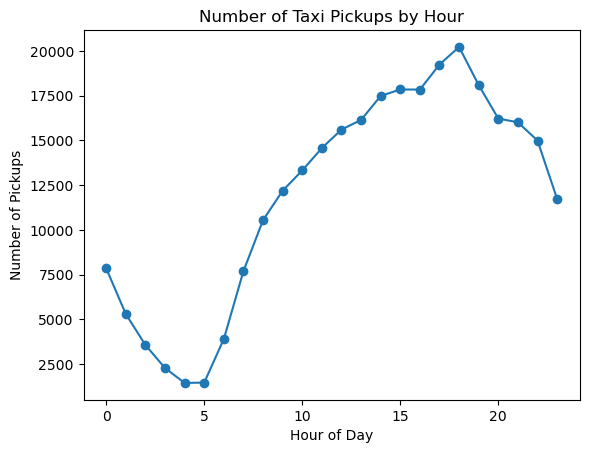

In [172]:
# Find and show the hourly trends in taxi pickups

#extract pickup_hour from tpep_pickup_datetime and get total number of taxi pickups in each hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_count = df['pickup_hour'].value_counts().sort_index()

print(hourly_count)

#plot the number of pickups on hourly basis

plt.plot(hourly_count.index, hourly_count.values, marker='o')
plt.title('Number of Taxi Pickups by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.show()

pickup_day_of_weekname
Monday       36129
Tuesday      41436
Wednesday    43892
Thursday     44734
Friday       42568
Saturday     41583
Sunday       36349
Name: count, dtype: int64


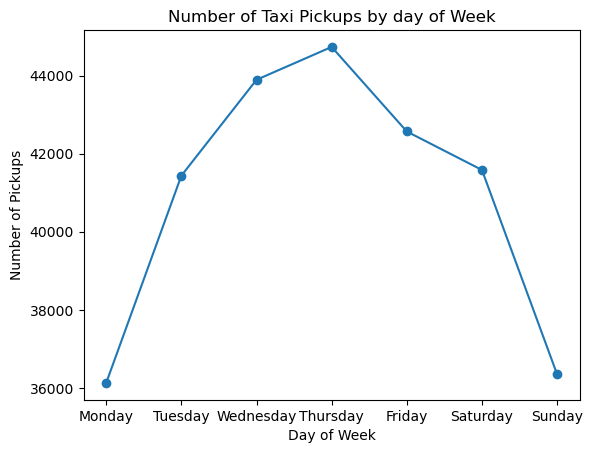

In [161]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
#weekday_pickup = df['pickup_day_of_week'].value_counts().sort_index()
#print(weekday_pickup)

day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['pickup_day_of_weekname'] = df['pickup_day_of_week'].map(day_names)
weekday_pickup_count = df['pickup_day_of_weekname'].value_counts()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_pickup_count = weekday_pickup_count.reindex(day_order)
print(weekday_pickup_count)

#plot the number of pickups on day of week basis

plt.plot(weekday_pickup_count.index, weekday_pickup_count.values, marker='o')
plt.title('Number of Taxi Pickups by day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.show()

pickup_month
1     23126
2     22129
3     25472
4     24503
5     26464
6     24753
7     21960
8     21023
9     20941
10    25889
11    24794
12    24491
Name: count, dtype: int64


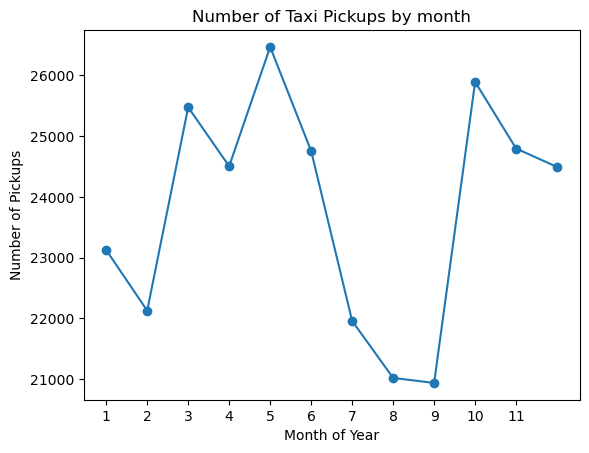

In [173]:
# Show the monthly trends in pickups

#extract pickup_month from tpep_pickup_datetime and get total number of taxi pickups in each month
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
monthly_count = df['pickup_month'].value_counts().sort_index()

print(monthly_count)

#plot the number of pickups on monthly basis

plt.plot(monthly_count.index, monthly_count.values, marker='o')
plt.title('Number of Taxi Pickups by month')
plt.xlabel('Month of Year')
plt.ylabel('Number of Pickups')
plt.xticks(range(1,12))
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [174]:
# Analyse the above parameters
financial_col = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in financial_col:
    num_zeroes = (df[col] == 0).sum()
    num_negatives = (df[col] < 0).sum()
    print(f"{col}: Zeroes = {num_zeroes}, Negatives = {num_negatives}")
    

fare_amount: Zeroes = 20, Negatives = 0
tip_amount: Zeroes = 64049, Negatives = 0
total_amount: Zeroes = 0, Negatives = 0
trip_distance: Zeroes = 2294, Negatives = 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [177]:
# Create a df with non zero entries for the selected parameters.

df_non_zero = df[(df['fare_amount'] > 0) &
                 (df['tip_amount'] > 0) &
                 (df['trip_distance'] > 0) &
                 (df['total_amount'] > 0)].copy()
print(df.shape[0],df_non_zero.shape[0])

285545 220750


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

pickup_month
1     615174.95
2     587268.54
3     691646.70
4     680334.59
5     751186.37
6     697125.46
7     613801.11
8     593160.80
9     608005.21
10    739245.90
11    701219.55
12    689216.70
Name: total_amount, dtype: float64


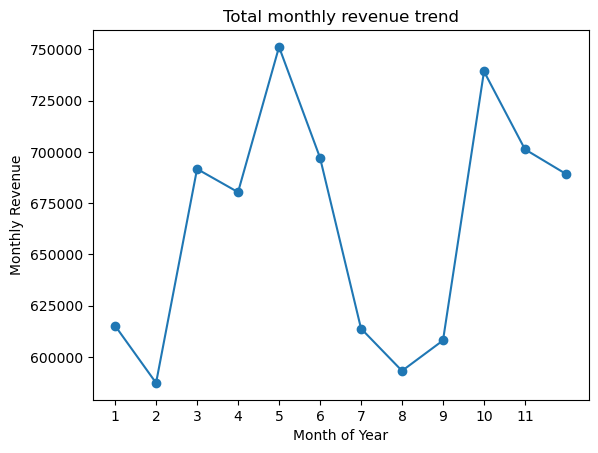

In [179]:
# Group data by month and analyse monthly revenue
# we have already extracted pickup month previously, so now just getting the total revenue each month basis
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()
print(monthly_revenue)

#plotting calculated revenue on monthly basis
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Total monthly revenue trend')
plt.xlabel('Month of Year')
plt.ylabel('Monthly Revenue')
plt.xticks(range(1,12))
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

pickup_quarter
1    1894090.19
2    2128646.42
3    1814967.12
4    2129682.15
Name: total_amount, dtype: float64


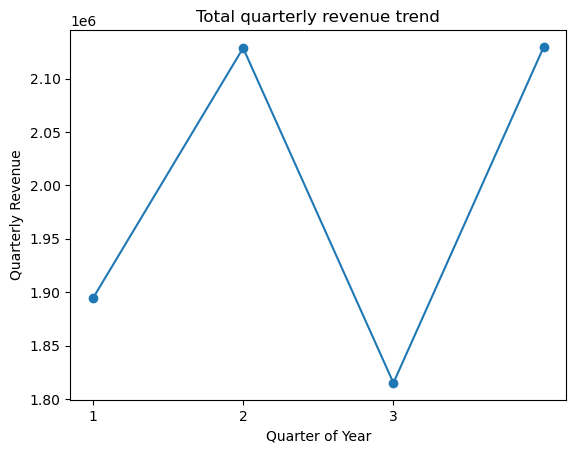

In [180]:
# Calculate proportion of each quarter
#extracting quarter values from the pickup datetime and calculating total revenue in each quarter
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
print(quarterly_revenue)

#plotting calculated revenue on quarterly basis
plt.plot(quarterly_revenue.index, quarterly_revenue.values, marker='o')
plt.title('Total quarterly revenue trend')
plt.xlabel('Quarter of Year')
plt.ylabel('Quarterly Revenue')
plt.xticks(range(1,4))
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

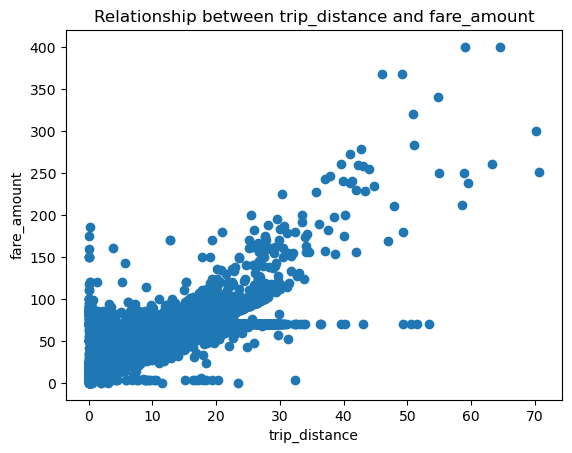

correlation between trip_distance and fare_amount is  0.9493557378271462


In [188]:
# Show how trip fare is affected by distance
df_trip_dist_nonzero = df[(df['trip_distance'] > 0)]

#plotting scatter plot between trip_distance and fare_amount to see how both the variables are corelated to each other
plt.scatter(df_trip_dist_nonzero['trip_distance'],df_trip_dist_nonzero['fare_amount'])
plt.title('Relationship between trip_distance and fare_amount')
plt.xlabel('trip_distance')
plt.ylabel('fare_amount')
plt.show()

#calculating corelation between trip_distance and fare_amount
correlation_dist_fare = df_trip_dist_nonzero['trip_distance'].corr(df_trip_dist_nonzero['fare_amount'])
print('correlation between trip_distance and fare_amount is ',correlation_dist_fare)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

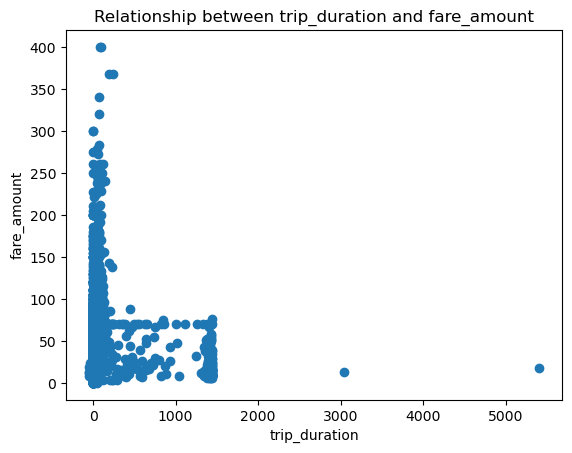

correlation between trip_duration and fare_amount is  0.25911948097683335


In [189]:
# Show relationship between fare and trip duration

#calculate trip duration by subtracting pickup time from dropoff time, converting it to seconds and then dividing by 60
#to get total minutes of trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

#plotting scatter plot between trip_duration and fare_amount to see how both the variables are corelated to each other
plt.scatter(df['trip_duration'],df['fare_amount'])
plt.title('Relationship between trip_duration and fare_amount')
plt.xlabel('trip_duration')
plt.ylabel('fare_amount')
plt.show()

#calculating corelation between trip_distance and fare_amount
correlation_duration_fare = df['trip_duration'].corr(df['fare_amount'])
print('correlation between trip_duration and fare_amount is ',correlation_duration_fare)

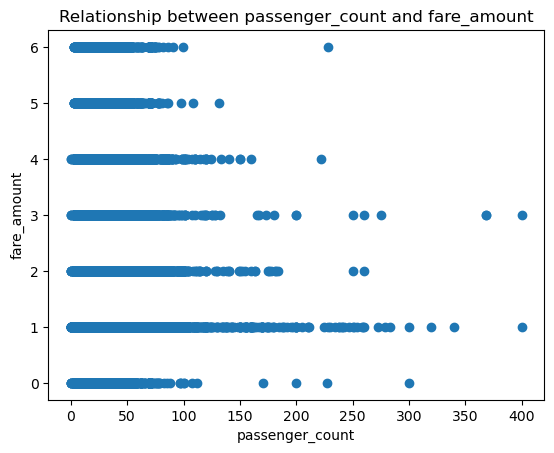

correlation between passenger_count and fare_amount is  0.04272705946396088


In [191]:
# Show relationship between fare and number of passengers

#plotting scatter plot between passenger_count and fare_amount to see how both the variables are corelated to each other
plt.scatter(df['passenger_count'],df['fare_amount'])
plt.title('Relationship between passenger_count and fare_amount')
plt.xlabel('passenger_count')
plt.ylabel('fare_amount')
plt.show()

#calculating corelation between passenger_count and fare_amount
correlation_passcount_fare = df['passenger_count'].corr(df['fare_amount'])
print('correlation between passenger_count and fare_amount is ',correlation_passcount_fare)

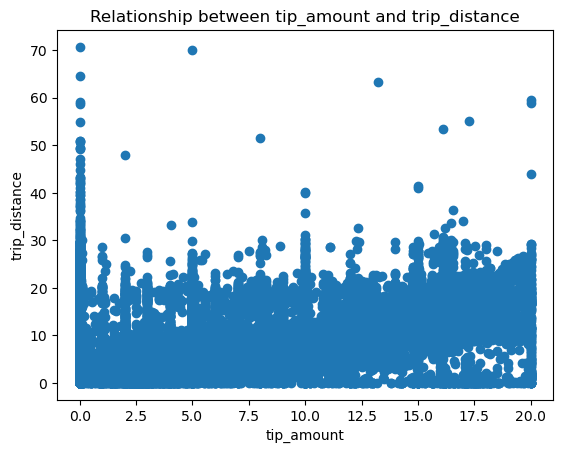

correlation between tip_amount and trip_distance is  0.5684849466389834


In [192]:
# Show relationship between tip and trip distance

#plotting scatter plot between tip_amount and trip_distance to see how both the variables are corelated to each other
plt.scatter(df['tip_amount'],df['trip_distance'])
plt.title('Relationship between tip_amount and trip_distance')
plt.xlabel('tip_amount')
plt.ylabel('trip_distance')
plt.show()

#calculating corelation between tip_amount and trip_distance
correlation_tip_distance = df['tip_amount'].corr(df['trip_distance'])
print('correlation between tip_amount and trip_distance is ',correlation_tip_distance)


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type_name
Credit card    232169
Cash            49799
Dispute          2129
No charge        1448
Name: count, dtype: int64


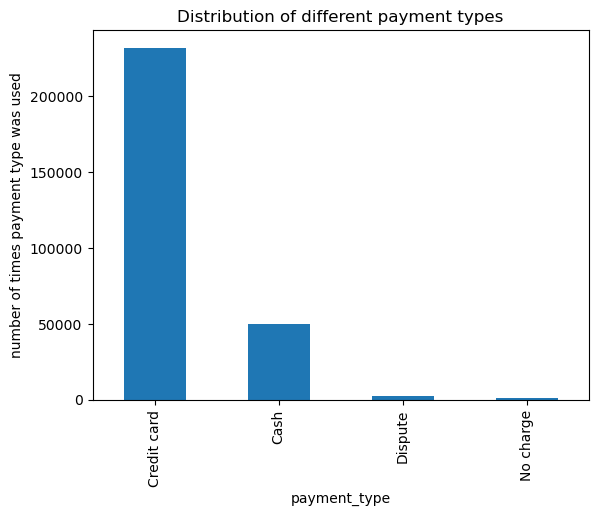

In [199]:
# Analyse the distribution of different payment types (payment_type).

#first get count of all the payments done with each payment type
#payment_type_count = df['payment_type'].value_counts()
#print(payment_type_count)

#instead of first getting counts of each payment type, we will first map the payment type description/name 
#to each payment type numerical value and then get the counts of each payment type
payment_type_desc = {1:'Credit card', 2:'Cash', 3:'No charge', 4:'Dispute'}
df['payment_type_name'] = df['payment_type'].map(payment_type_desc)
payment_type_count = df['payment_type_name'].value_counts()
print(payment_type_count)

#plotting bar chart between payment_type and payment_type_count to see the distribution of different payment types
payment_type_count.plot(kind='bar')
plt.title('Distribution of different payment types')
plt.xlabel('payment_type')
plt.ylabel('number of times payment type was used')
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [200]:
# !pip install geopandas
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 21.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [pyogrio]


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [201]:
# import geopandas as gpd

import geopandas as gpd
# Read the shapefile using geopandas
zones = gpd.read_file('/Users/deekshasrivastava/Downloads/AI_ML_MainCourse_Files/EDA Assignment/Datasets and Dictionary/taxi_zones/taxi_zones.shp')# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

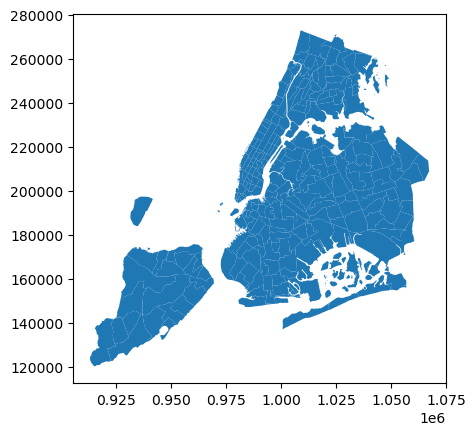

In [202]:
# print(zones.info())
# zones.plot()
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [207]:
# Merge zones and trip records using LocationID and PULocationID

#merging trip records with taxi zones using PULocationID and LocationID respectively from each data and left joining both the data
df_merged_data = df.merge(zones, left_on = 'PULocationID', right_on = 'LocationID', how='left')
df_merged_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_quarter,trip_duration,payment_type_name,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,2023-09-28 09:13:40,2023-09-28 09:18:59,1.0,0.70,1.0,N,68,158,1,...,3,5.316667,Credit card,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."
1,2,2023-08-27 18:00:07,2023-08-27 18:13:13,1.0,2.47,1.0,N,142,236,1,...,3,13.100000,Credit card,142.0,0.038176,0.000076,Lincoln Square East,142.0,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
2,2,2023-08-05 21:26:26,2023-08-05 21:44:12,1.0,3.11,1.0,N,13,90,2,...,3,17.766667,Cash,13.0,0.050281,0.000149,Battery Park City,13.0,Manhattan,"POLYGON ((980801.31 201248.869, 980697.386 200..."
3,1,2023-02-28 20:11:57,2023-02-28 20:27:28,1.0,2.50,1.0,N,236,164,1,...,1,15.516667,Credit card,236.0,0.044252,0.000103,Upper East Side North,236.0,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220..."
4,2,2023-10-19 00:00:32,2023-10-19 00:11:52,1.0,2.52,1.0,N,79,162,1,...,4,11.333333,Credit card,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [211]:
# Group data by location and calculate the number of trips
num_trip_grpby_location = df.groupby('PULocationID').size().reset_index(name = 'num_of_trips')

print(num_trip_grpby_location)


     PULocationID  num_of_trips
0               1            24
1               3             4
2               4           287
3               7           124
4               8             1
..            ...           ...
230           261          1414
231           262          3774
232           263          5445
233           264          2757
234           265           100

[235 rows x 2 columns]


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [212]:
# Merge trip counts back to the zones GeoDataFrame
num_trip_merged_zone = zones.merge(num_trip_grpby_location, left_on = 'LocationID', right_on = 'PULocationID', how = 'left')
num_trip_merged_zone.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,num_of_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,24.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,4.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,287.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

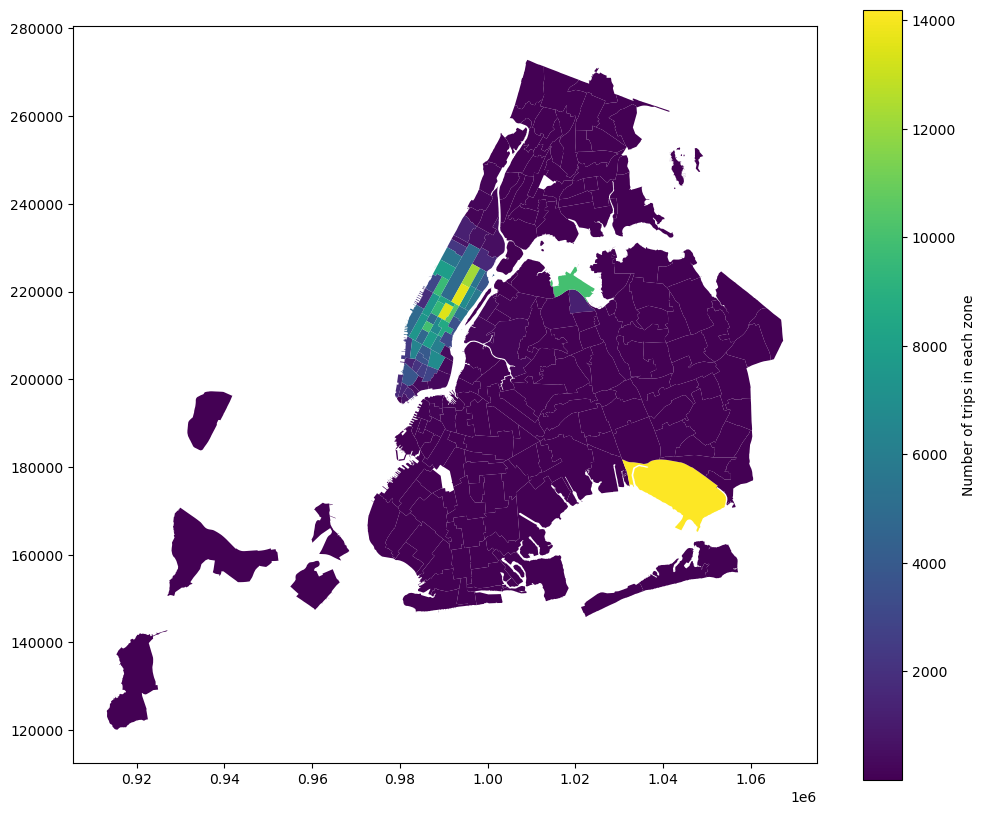

In [214]:
# Define figure and axis
fig, ax=plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
num_trip_merged_zone.plot(column = 'num_of_trips',
                          ax = ax,
                          legend = True,
                          legend_kwds = {'label': 'Number of trips in each zone', 'orientation':'vertical'})
plt.show()


     OBJECTID  Shape_Leng  Shape_Area                       zone  LocationID  \
220       221    0.166218    0.000890                  Stapleton         221   
45         46    0.134475    0.000926                City Island          46   
252       253    0.036051    0.000078              Willets Point         253   
10         11    0.079211    0.000265                 Bath Beach          11   
152       153    0.024737    0.000032                Marble Hill         153   
..        ...         ...         ...                        ...         ...   
203       204    0.101912    0.000641          Rossville/Woodrow         204   
205       206    0.212757    0.000944  Saint George/New Brighton         206   
244       245    0.095983    0.000466              West Brighton         245   
250       251    0.137711    0.000626                Westerleigh         251   
256       257    0.058669    0.000139            Windsor Terrace         257   

           borough                     

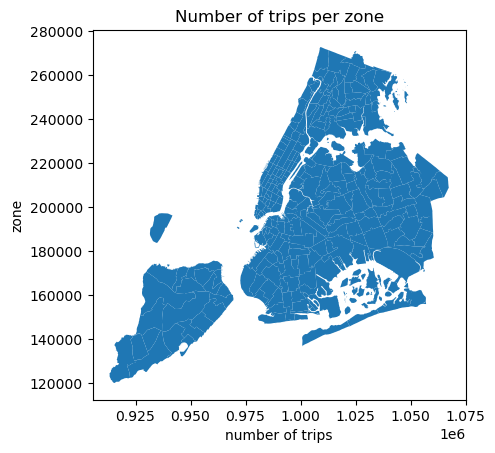

In [288]:
# can you try displaying the zones DF sorted by the number of trips?
zones_num_trips_sorted = num_trip_merged_zone.sort_values('num_of_trips')
print(zones_num_trips_sorted)
#num_trip_merged_zone.head()

zones_num_trips_sorted.plot()
plt.title('Number of trips per zone')
plt.xlabel('number of trips')
plt.ylabel('zone')
plt.show()

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [233]:
# Find routes which have the slowest speeds at different times of the day

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['pu_hour'] = df['tpep_pickup_datetime'].dt.hour

df['new_trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

all_route = df.groupby(['PULocationID', 'DOLocationID', 'pu_hour']).agg({'trip_distance':'mean','trip_duration':'mean'}).reset_index()
#all_route.info()

all_route['speed'] = all_route['trip_distance'] / all_route['trip_duration']
all_route_slowest_first = all_route.sort_values('speed')
print(all_route_slowest_first)


       PULocationID  DOLocationID  pu_hour  trip_distance  trip_duration  \
5974             50           239        1       1.770000     -12.838889   
12824            90            88        1       3.750000     -34.516667   
55594           238           263        1       1.490000     -22.158333   
43839           193           193       16       0.000000       0.408333   
23372           137           137        2       0.000000       0.233333   
...             ...           ...      ...            ...            ...   
58012           248           248       22      16.700000       0.416667   
62569           265           265        8      23.366667       0.483333   
43923           197           197        2       2.500000       0.050000   
1374             23            23       10      20.300000       0.366667   
19582           130           130       13      19.400000       0.033333   

            speed  
5974    -0.137862  
12824   -0.108643  
55594   -0.067243  
43839  

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

pickup_hour
18    20223
17    19237
19    18089
15    17845
16    17840
14    17483
20    16222
13    16142
21    16010
12    15604
22    14992
11    14570
10    13319
9     12189
23    11733
8     10542
0      7851
7      7692
1      5298
6      3903
2      3568
3      2279
5      1466
4      1448
Name: count, dtype: int64


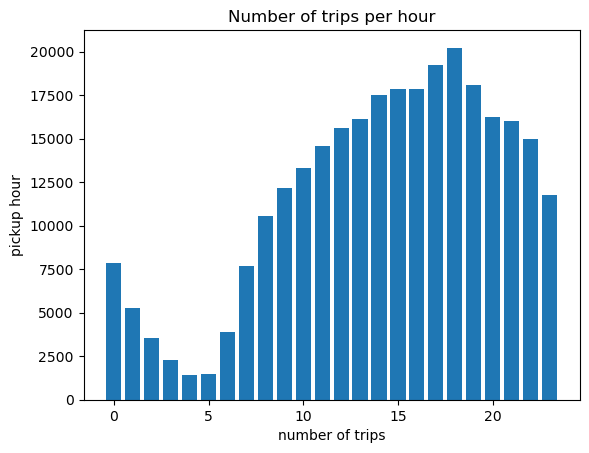

busiest hour is  18  and total trips in busiest hour is  20223


In [237]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = df['pickup_hour'].value_counts()
print(trips_per_hour)

plt.bar(trips_per_hour.index,trips_per_hour.values)
plt.title('Number of trips per hour')
plt.xlabel('number of trips')
plt.ylabel('pickup hour')
plt.show()

busiest_hour = trips_per_hour.idxmax()
max_num_trips = trips_per_hour.max()
print('busiest hour is ',busiest_hour,' and total trips in busiest hour is ',max_num_trips)

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [239]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

top_five_busiest_trips = trips_per_hour.sort_values(ascending = False).head()
#print(top_five_busiest_trips)

actual_trip_count_top_five_busiest = top_five_busiest_trips / sample_fraction
print(actual_trip_count_top_five_busiest)


pickup_hour
18    404460.0
17    384740.0
19    361780.0
15    356900.0
16    356800.0
Name: count, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

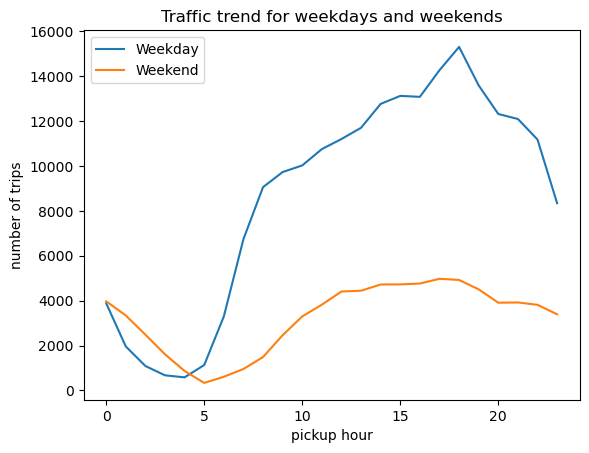

In [248]:
# Compare traffic trends for the week days and weekends
#df.info()
weekday_df = df[df['pickup_day_of_week'] < 5]
weekend_df = df[df['pickup_day_of_week'] >= 5]

weekday_traffic = weekday_df['pickup_hour'].value_counts().sort_index()
weekend_traffic = weekend_df['pickup_hour'].value_counts().sort_index()

#weekend_traffic.head()

plt.plot(weekday_traffic.index, weekday_traffic.values, label='Weekday')
plt.plot(weekend_traffic.index, weekend_traffic.values, label='Weekend')
plt.title('Traffic trend for weekdays and weekends')
plt.ylabel('number of trips')
plt.xlabel('pickup hour')
plt.legend()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

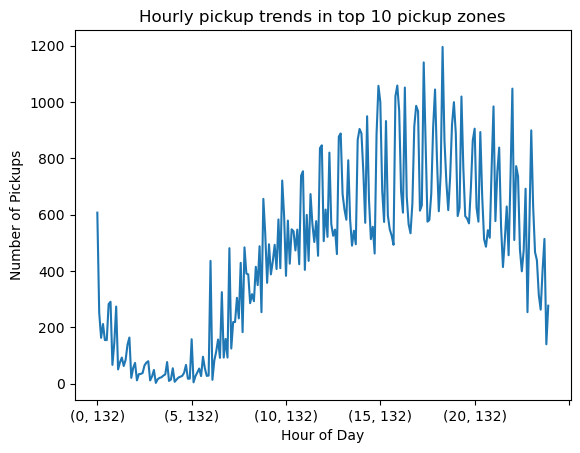

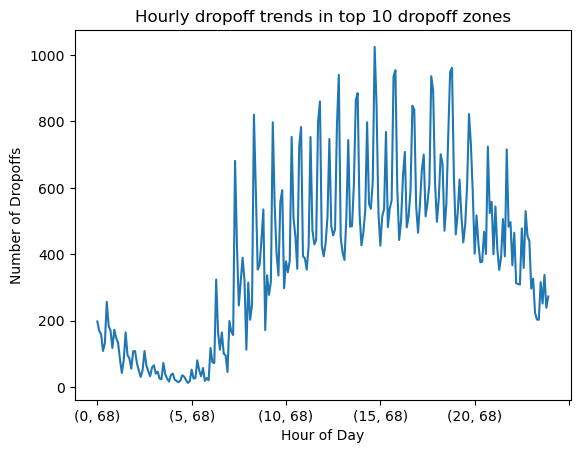

In [251]:
# Find top 10 pickup and dropoff zones

pickup_counts = df['PULocationID'].value_counts()
dropoff_counts = df['DOLocationID'].value_counts()

top_10_pickup = pickup_counts.head(10)
top_10_dropoff = dropoff_counts.head(10)

pickup_trends = df[df['PULocationID'].isin(top_10_pickup.index)]
dropoff_trends = df[df['DOLocationID'].isin(top_10_dropoff.index)]

pickup_hourly_trend = pickup_trends.groupby(['pickup_hour','PULocationID']).size()
dropoff_hourly_trend = dropoff_trends.groupby(['pickup_hour','DOLocationID']).size()

pickup_hourly_trend.plot()
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.title('Hourly pickup trends in top 10 pickup zones')
plt.show()

dropoff_hourly_trend.plot()
plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.title('Hourly dropoff trends in top 10 dropoff zones')
plt.show()




**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [252]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
ratio_df = pd.DataFrame({'pickups': pickup_counts,'dropoffs':dropoff_counts})
ratio_df['pickup_dropoff_ratio'] = ratio_df['pickups'] / ratio_df['dropoffs']

top_10_ratio = ratio_df.sort_values('pickup_dropoff_ratio', ascending = False).head(10)
bottom_10_ratio = ratio_df.sort_values('pickup_dropoff_ratio', ascending = True).head(10)

print('Top 10 pickup/dropoff ratio',top_10_ratio)
print('Bottom 10 pickup/dropoff ratio',bottom_10_ratio)

Top 10 pickup/dropoff ratio      pickups  dropoffs  pickup_dropoff_ratio
70    1260.0       147              8.571429
132  14194.0      3076              4.614434
138   9946.0      3512              2.832005
186   9978.0      6404              1.558089
43    4911.0      3533              1.390037
249   6395.0      4849              1.318829
114   3706.0      2839              1.305389
162  10400.0      8260              1.259080
100   4756.0      3966              1.199193
161  13508.0     11325              1.192759
Bottom 10 pickup/dropoff ratio      pickups  dropoffs  pickup_dropoff_ratio
67       1.0        40              0.025000
198      5.0       142              0.035211
92      10.0       229              0.043668
243     21.0       467              0.044968
37      13.0       273              0.047619
217      6.0       119              0.050420
112     33.0       641              0.051482
171      3.0        52              0.057692
49      24.0       395              0.060

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [254]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_hour_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]
night_pickup_count = night_hour_df['PULocationID'].value_counts().head(10)
night_dropoff_count = night_hour_df['DOLocationID'].value_counts().head(10)

print('Top 10 pickup locations during night hours is',night_pickup_count)
print('Top 10 dropoff locations during night hours is',night_dropoff_count)


Top 10 pickup locations during night hours is PULocationID
79     2478
132    2116
249    1951
48     1611
148    1543
114    1347
230    1248
186    1067
138     960
68      945
Name: count, dtype: int64
Top 10 dropoff locations during night hours is DOLocationID
79     1292
48     1068
170     989
68      912
107     861
249     827
263     794
141     793
230     729
236     710
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [255]:
# Filter for night hours (11 PM to 5 AM)
day_hour_df = df[(df['pickup_hour'] >= 6) | (df['pickup_hour'] <= 22)]

night_revenue = night_hour_df['total_amount'].sum()
day_revenue = day_hour_df['total_amount'].sum()

night_revenue_percent = (night_revenue/(night_revenue + day_revenue)) * 100
day_revenue_percent = (day_revenue/(night_revenue + day_revenue)) * 100
print('Night time revenue and percent share is ',night_revenue,' & ',night_revenue_percent)
print('Day time revenue and percent share is ',day_revenue,' & ',day_revenue_percent)



Night time revenue and percent share is  950734.01  &  10.660700032369718
Day time revenue and percent share is  7967385.879999999  &  89.33929996763028


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [257]:
# Analyse the fare per mile per passenger for different passenger counts

df_non_zero_trips = df[df['trip_distance'] > 0]
df_non_zero_trips['fare_per_mile'] = df_non_zero_trips['fare_amount']/df_non_zero_trips['trip_distance']

fare_by_passenger_count = df_non_zero_trips.groupby('passenger_count')['fare_per_mile'].mean()

fare_per_passenger = fare_by_passenger_count/fare_by_passenger_count.index
print(fare_per_passenger)




passenger_count
0.0          inf
1.0    10.421010
2.0     6.347169
3.0     4.117849
4.0     3.427642
5.0     1.713489
6.0     1.344361
dtype: float64


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

fare per mile by hours is  pickup_hour
0      9.508761
1      8.676073
2      8.407246
3      8.072236
4     12.730780
5     10.941007
6     12.081015
7     11.341267
8      9.471088
9     10.235707
10    10.356774
11    11.257599
12    11.393593
13    12.470431
14    10.902332
15    11.700859
16    13.534263
17    11.328386
18    13.430943
19    10.583271
20     8.994690
21     9.070819
22     8.273934
23     9.745915
Name: fare_per_mile, dtype: float64
fare per mile by day of week is  pickup_day_of_week
0    10.832768
1    10.866691
2     9.987621
3    11.654700
4    11.811775
5    10.407654
6    10.190632
Name: fare_per_mile, dtype: float64


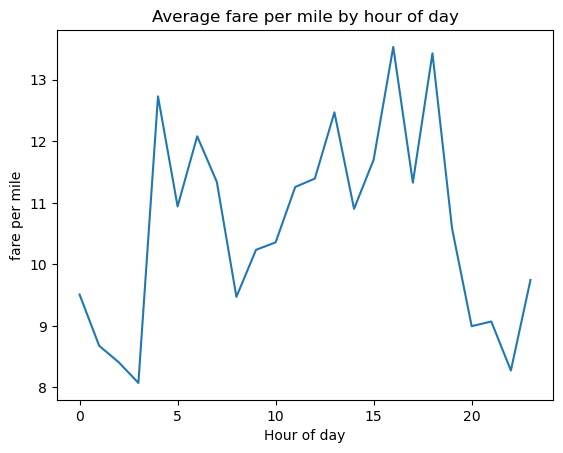

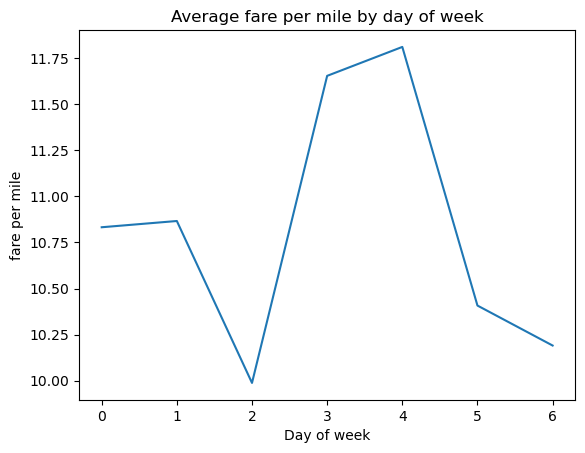

In [259]:
# Compare the average fare per mile for different days and for different times of the day

fare_by_hour = df_non_zero_trips.groupby('pickup_hour')['fare_per_mile'].mean()
fare_by_day_of_week = df_non_zero_trips.groupby('pickup_day_of_week')['fare_per_mile'].mean()

print('fare per mile by hours is ',fare_by_hour)
print('fare per mile by day of week is ',fare_by_day_of_week)

plt.plot(fare_by_hour.index, fare_by_hour.values)
plt.title('Average fare per mile by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('fare per mile')
plt.show()

plt.plot(fare_by_day_of_week.index, fare_by_day_of_week.values)
plt.title('Average fare per mile by day of week')
plt.xlabel('Day of week')
plt.ylabel('fare per mile')
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

Average fare per mile for different vendors for different hours of the day is VendorID  pickup_hour
1         0               6.722563
          1               7.363963
          2               6.627360
          3               6.460720
          4               7.542076
          5               7.299453
          6               6.450567
          7               7.193700
          8               7.839402
          9               8.463535
          10              8.528940
          11              8.787579
          12              8.663039
          13              8.688940
          14              8.601401
          15              8.676219
          16              8.722865
          17              8.756665
          18              8.320399
          19              7.876534
          20              7.828778
          21              7.287339
          22              7.072037
          23              6.959233
2         0              10.303829
          1              

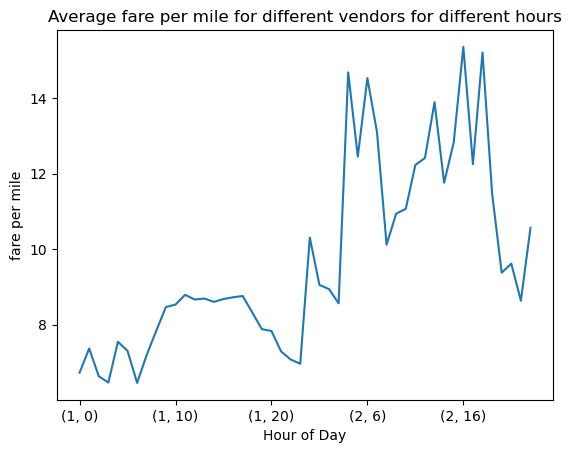

In [262]:
# Compare fare per mile for different vendors

fare_by_vendor_hour = df_non_zero_trips.groupby(['VendorID','pickup_hour'])['fare_per_mile'].mean()

print('Average fare per mile for different vendors for different hours of the day is',fare_by_vendor_hour)
fare_by_vendor_hour.plot()
plt.title('Average fare per mile for different vendors for different hours')
plt.xlabel('Hour of Day')
plt.ylabel('fare per mile')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


fare rates of the different vendors in a tiered fashion VendorID  distance_tier
1         0-2 miles         9.850047
          2-5 miles         5.662065
2         0-2 miles        16.738317
          2-5 miles         5.763248
Name: fare_per_mile, dtype: float64


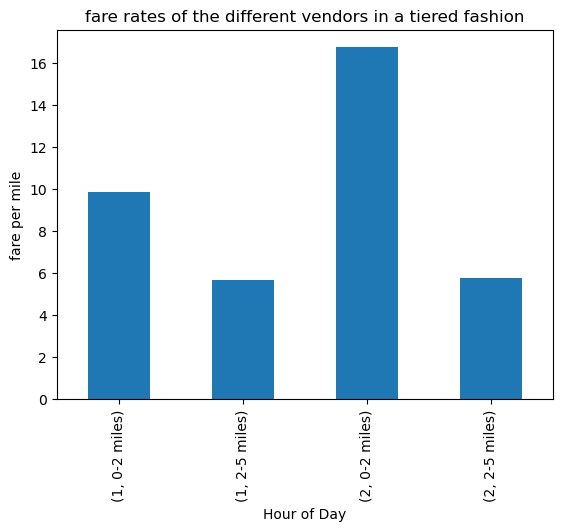

In [268]:
# Defining distance tiers
conditions = [df_non_zero_trips['trip_distance'] <= 2, (df_non_zero_trips['trip_distance'] > 2) | (df_non_zero_trips['trip_distance'] <= 5),
    df_non_zero_trips['trip_distance'] > 5
]
choices = ['0-2 miles', '2-5 miles', 'more than 5 miles']
df_non_zero_trips['distance_tier'] = np.select(conditions,choices)

fare_by_vendor_disttier = df_non_zero_trips.groupby(['VendorID','distance_tier'])['fare_per_mile'].mean()
print('fare rates of the different vendors in a tiered fashion',fare_by_vendor_disttier)

fare_by_vendor_disttier.plot(kind='bar')
plt.title('fare rates of the different vendors in a tiered fashion')
plt.xlabel('Hour of Day')
plt.ylabel('fare per mile')
plt.show()



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

tip % by distance tiers distance_tier
0-2 miles    23.360534
2-5 miles    17.686385
Name: tip_percentage, dtype: float64
tip % by passenger count passenger_count
0.0    19.320591
1.0    20.511022
2.0    23.998894
3.0    18.727456
4.0    16.894456
5.0    20.470472
6.0    20.865841
Name: tip_percentage, dtype: float64
tip % by pickup hour pickup_hour
0     20.394742
1     20.597650
2     20.089578
3     19.500511
4     17.324617
5     17.229817
6     17.930041
7     19.519388
8     19.781259
9     19.571617
10    19.107151
11    18.950491
12    18.950541
13    19.136628
14    30.040073
15    18.818809
16    20.619516
17    21.409282
18    22.055946
19    21.847346
20    21.173020
21    21.239714
22    21.175657
23    20.592971
Name: tip_percentage, dtype: float64


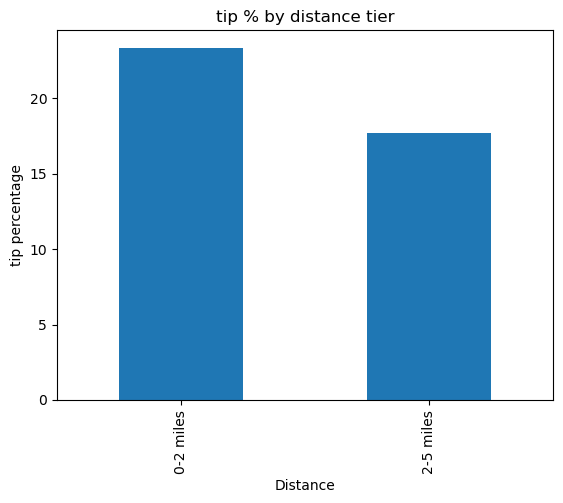

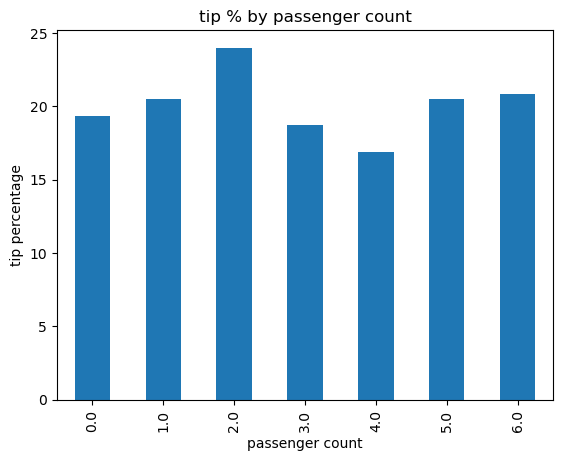

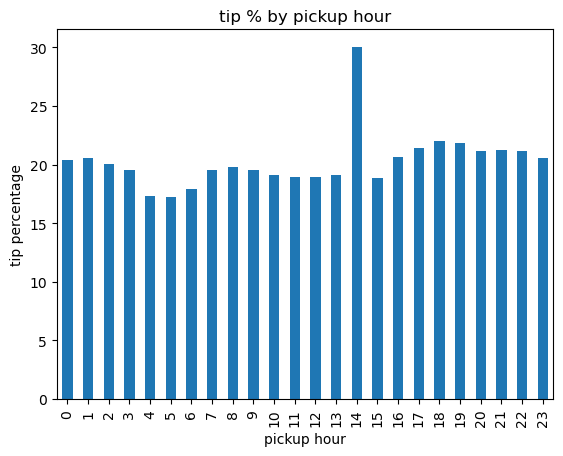

In [273]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_non_zero_fare = df[df['fare_amount']>0]
df_non_zero_fare['tip_percentage'] = (df_non_zero_fare['tip_amount']/df_non_zero_fare['fare_amount']) * 100

conditions = [df_non_zero_fare['trip_distance'] <= 2, (df_non_zero_fare['trip_distance'] > 2) | (df_non_zero_fare['trip_distance'] <= 5),
    df_non_zero_fare['trip_distance'] > 5
]
choices = ['0-2 miles', '2-5 miles', 'more than 5 miles']
df_non_zero_fare['distance_tier'] = np.select(conditions,choices)

tip_by_distance = df_non_zero_fare.groupby('distance_tier')['tip_percentage'].mean()
tip_by_pass_count = df_non_zero_fare.groupby('passenger_count')['tip_percentage'].mean()
tip_by_pickup_hour = df_non_zero_fare.groupby('pickup_hour')['tip_percentage'].mean()

print('tip % by distance tiers',tip_by_distance)
print('tip % by passenger count',tip_by_pass_count)
print('tip % by pickup hour',tip_by_pickup_hour)

tip_by_distance.plot(kind='bar')
plt.title('tip % by distance tier')
plt.xlabel('Distance')
plt.ylabel('tip percentage')
plt.show()

tip_by_pass_count.plot(kind='bar')
plt.title('tip % by passenger count')
plt.xlabel('passenger count')
plt.ylabel('tip percentage')
plt.show()

tip_by_pickup_hour.plot(kind='bar')
plt.title('tip % by pickup hour')
plt.xlabel('pickup hour')
plt.ylabel('tip percentage')
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

passenger count by pickup hour pickup_hour
0     1.400713
1     1.408834
2     1.441143
3     1.438789
4     1.407459
5     1.257844
6     1.215731
7     1.238820
8     1.266458
9     1.289523
10    1.336362
11    1.354839
12    1.359844
13    1.350824
14    1.368758
15    1.392939
16    1.379933
17    1.377710
18    1.352272
19    1.379512
20    1.384540
21    1.412742
22    1.414221
23    1.406119
Name: passenger_count, dtype: float64
passenger count by day of week pickup_day_of_week
0    1.337966
1    1.313924
2    1.311096
3    1.324207
4    1.380148
5    1.457401
6    1.438590
Name: passenger_count, dtype: float64


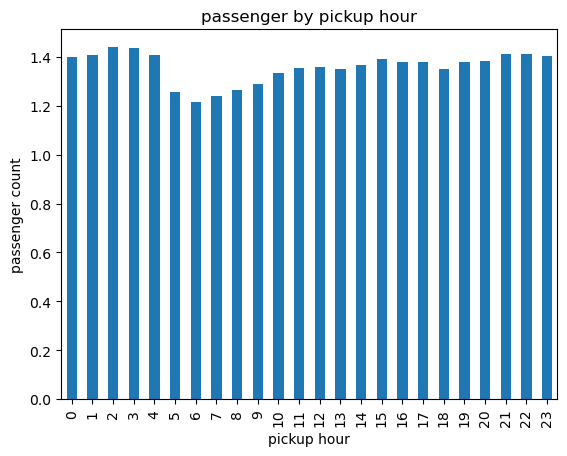

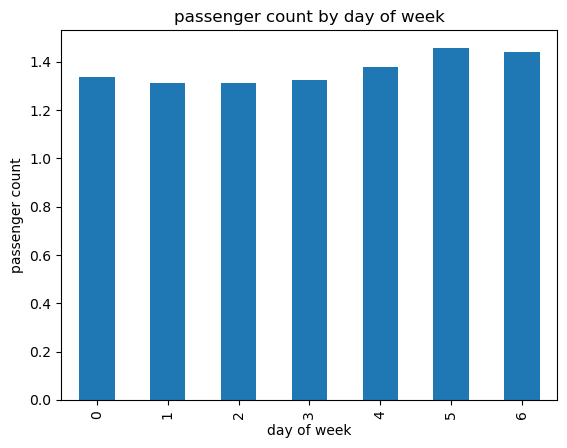

In [276]:
# See how passenger count varies across hours and days

pass_by_hour = df.groupby('pickup_hour')['passenger_count'].mean()
pass_by_day = df.groupby('pickup_day_of_week')['passenger_count'].mean()

print('passenger count by pickup hour',pass_by_hour)
print('passenger count by day of week',pass_by_day)

pass_by_hour.plot(kind='bar')
plt.title('passenger by pickup hour')
plt.xlabel('pickup hour')
plt.ylabel('passenger count')
plt.show()

pass_by_day.plot(kind='bar')
plt.title('passenger count by day of week')
plt.xlabel('day of week')
plt.ylabel('passenger count')
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

passenger count accross different zones PULocationID
1      1.750000
3      1.000000
4      1.432056
7      1.201613
8      1.000000
         ...   
261    1.485856
262    1.316375
263    1.316253
264    1.319550
265    1.520000
Name: passenger_count, Length: 235, dtype: float64


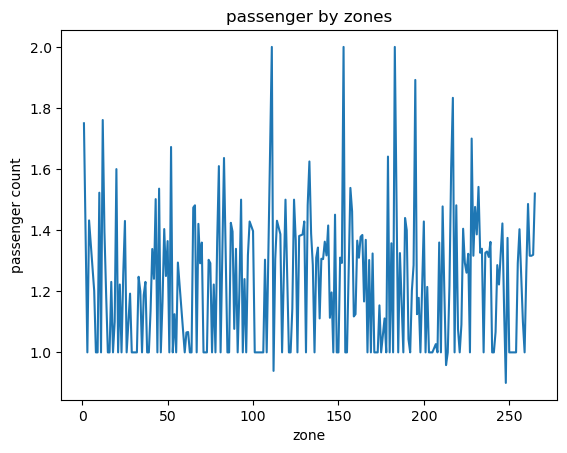

In [278]:
# How does passenger count vary across zones

pass_by_zone = df.groupby('PULocationID')['passenger_count'].mean()
print('passenger count accross different zones',pass_by_zone)

pass_by_zone.plot()
plt.title('passenger by zones')
plt.xlabel('zone')
plt.ylabel('passenger count')
plt.show()

In [280]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
df_merged_data['avg_pass_count'] = df_merged_data['LocationID'].map(pass_by_zone)
print(df_merged_data[['LocationID','avg_pass_count']].head())



   LocationID  avg_pass_count
0        68.0        1.420769
1       142.0        1.362465
2        13.0        1.395770
3       236.0        1.326067
4        79.0        1.362513


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

extra charges by pickup hour pickup_hour
0      7564
1      5158
2      3496
3      2216
4      1333
5      1271
6      1282
7      2408
8      3175
9      3864
10     4156
11     4557
12     4782
13     4950
14     5395
15     5505
16    13681
17    15263
18    16312
19    14478
20    15499
21    15498
22    14467
23    11258
dtype: int64
extra charges by pickup zone PULocationID
1         1
4       225
7        44
10       24
12       89
       ... 
261     797
262    1826
263    3221
264    1537
265      12
Length: 172, dtype: int64
extra charges by dropoff zone DOLocationID
1         8
2         1
3        13
4       854
6         1
       ... 
261     850
262    3078
263    3958
264    1718
265     400
Length: 249, dtype: int64
improvement surcharge charges by pickup hour pickup_hour
0      7851
1      5298
2      3567
3      2278
4      1448
5      1466
6      3903
7      7691
8     10540
9     12189
10    13317
11    14570
12    15603
13    16140
14    17482
15    17842
16    17

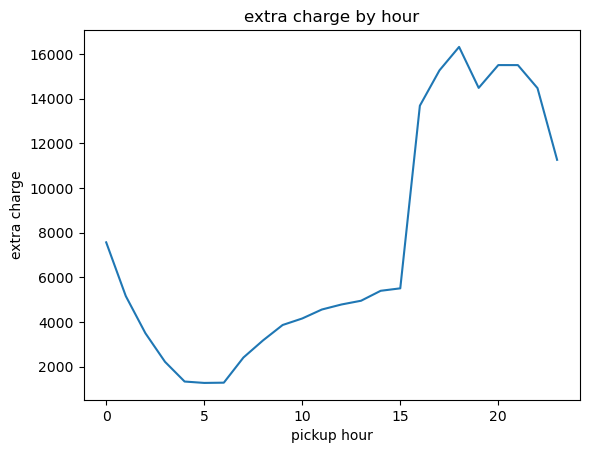

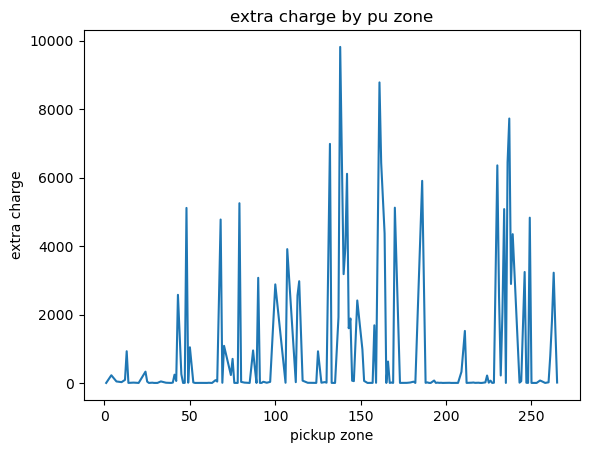

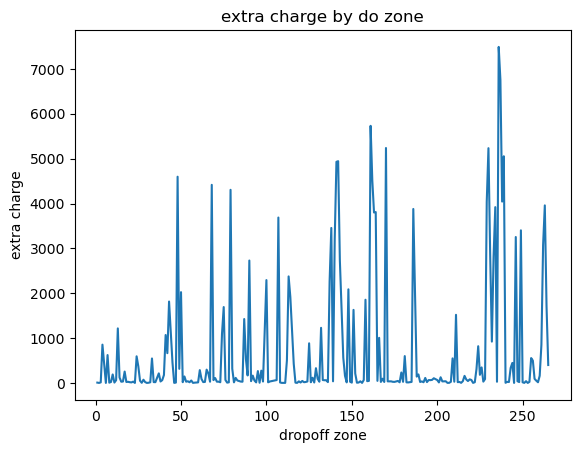

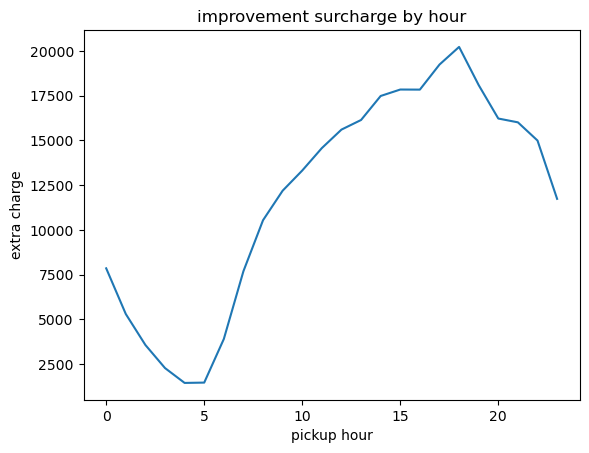

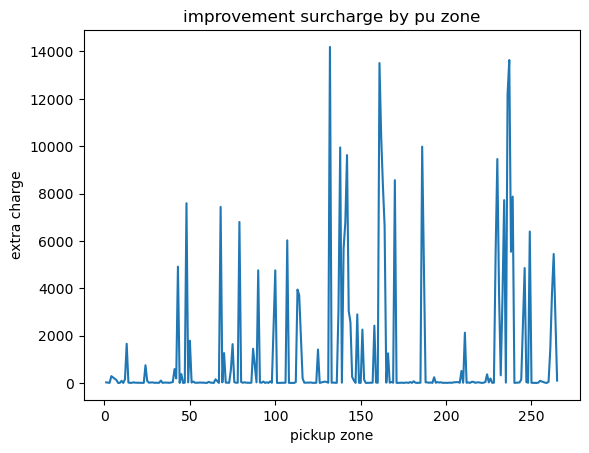

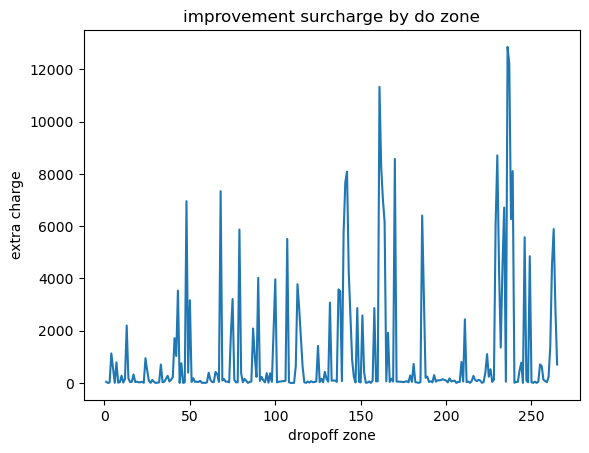

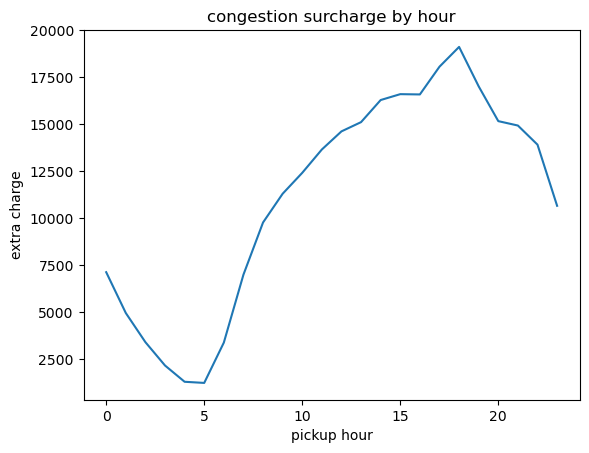

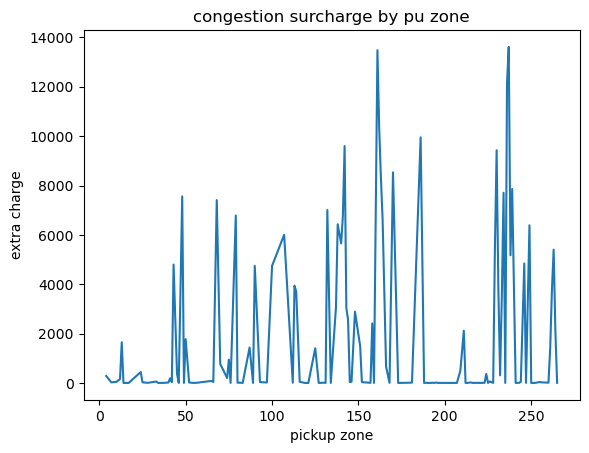

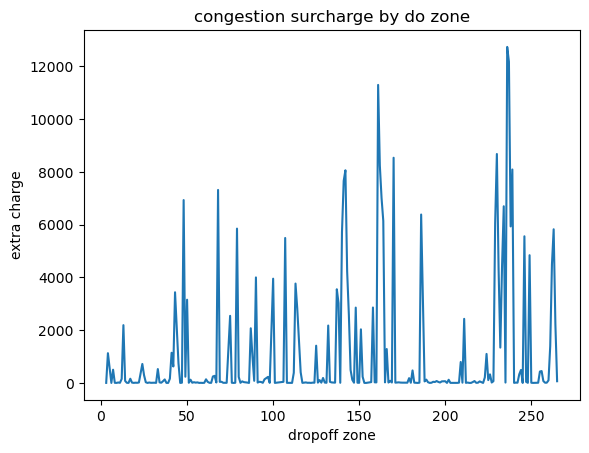

In [285]:
# How often is each surcharge applied?

extra_by_hour = df[df['extra'] > 0].groupby('pickup_hour').size()
extra_by_puzone = df[df['extra'] > 0].groupby('PULocationID').size()
extra_by_dozone = df[df['extra'] > 0].groupby('DOLocationID').size()

print('extra charges by pickup hour',extra_by_hour)
print('extra charges by pickup zone',extra_by_puzone)
print('extra charges by dropoff zone',extra_by_dozone)

impsur_by_hour = df[df['improvement_surcharge'] > 0].groupby('pickup_hour').size()
impsur_by_puzone = df[df['improvement_surcharge'] > 0].groupby('PULocationID').size()
impsur_by_dozone = df[df['improvement_surcharge'] > 0].groupby('DOLocationID').size()

print('improvement surcharge charges by pickup hour',impsur_by_hour)
print('improvement surcharge by pickup zone',impsur_by_puzone)
print('improvement surcharge by dropoff zone',impsur_by_dozone)

consur_by_hour = df[df['congestion_surcharge'] > 0].groupby('pickup_hour').size()
consur_by_puzone = df[df['congestion_surcharge'] > 0].groupby('PULocationID').size()
consur_by_dozone = df[df['congestion_surcharge'] > 0].groupby('DOLocationID').size()

print('congestion surcharge by pickup hour',consur_by_hour)
print('congestion surcharge by pickup zone',consur_by_puzone)
print('congestion surcharge by dropoff zone',consur_by_dozone)

extra_by_hour.plot()
plt.title('extra charge by hour')
plt.xlabel('pickup hour')
plt.ylabel('extra charge')
plt.show()

extra_by_puzone.plot()
plt.title('extra charge by pu zone')
plt.xlabel('pickup zone')
plt.ylabel('extra charge')
plt.show()

extra_by_dozone.plot()
plt.title('extra charge by do zone')
plt.xlabel('dropoff zone')
plt.ylabel('extra charge')
plt.show()

impsur_by_hour.plot()
plt.title('improvement surcharge by hour')
plt.xlabel('pickup hour')
plt.ylabel('extra charge')
plt.show()

impsur_by_puzone.plot()
plt.title('improvement surcharge by pu zone')
plt.xlabel('pickup zone')
plt.ylabel('extra charge')
plt.show()

impsur_by_dozone.plot()
plt.title('improvement surcharge by do zone')
plt.xlabel('dropoff zone')
plt.ylabel('extra charge')
plt.show()

consur_by_hour.plot()
plt.title('congestion surcharge by hour')
plt.xlabel('pickup hour')
plt.ylabel('extra charge')
plt.show()

consur_by_puzone.plot()
plt.title('congestion surcharge by pu zone')
plt.xlabel('pickup zone')
plt.ylabel('extra charge')
plt.show()

consur_by_dozone.plot()
plt.title('congestion surcharge by do zone')
plt.xlabel('dropoff zone')
plt.ylabel('extra charge')
plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

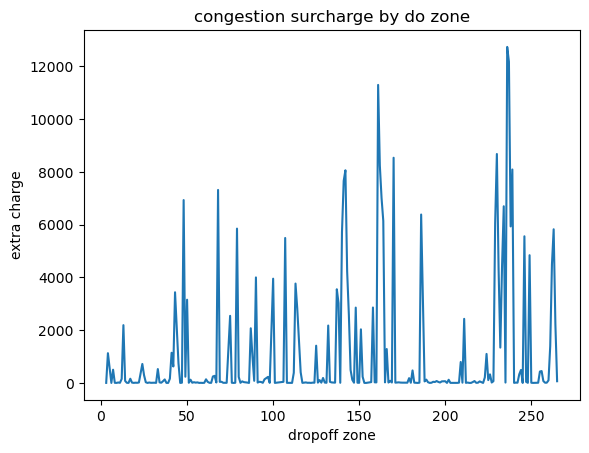

In [297]:
consur_by_dozone.plot()
plt.title('congestion surcharge by do zone')
plt.xlabel('dropoff zone')
plt.ylabel('extra charge')
plt.show

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
Based on the data on taxi trips provided and the above analysis done, we can see a clear demand pattern throughtout the day 
like increase in taxi demand during morning and evening time which could be because of people commuting to work.
We can also see this rising demand during weekdays while on weekends, demand is more in the night time. 
For recommendations to optimize routing and dispatching based on demand patterns and operational efficiencies, 
as we can see from the plot here, the demand of taxis is most during morning and evening time, what we can do is increase availability of
more taxis during these hours so that wait time for passengers is reduced and service will also improve
During weekends, taxis can be positioned near high-demand zones such as commercial areas, entertainment hubs etc.
For optimizing routes, alternative routes can be identified for routes with high congestion. Rerouting options can be made possible like in
google maps which tells real time traffic so if there is traffic, drivers can take a different route to reach to destination.
To conclude, to optimize routing and dispatching, taxi vendors should position more taxis in high demand zones. this high demand 
varies based on time and days of week, so positioning of taxis in these zones has to be dynamic, otherwise it will lead to more empty trips. 
Also, to reduce time between trips, real time traffic can be monitored and accordingly alternative routes can be suggested so that dusring 
such time or days when there is high traffic in a specific area, one can chose to reroute for a faster trip. Check report for detailed analysis

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
As mentioned in above step, we can see from the analysis that taxis have a high demand in morning and evening because of 
people going for work on weekdays while on weekends, we can see that the demand is more during night time peobably because 
of people going for movies or other entertainment hubs. We can also see the demand pattern based on zones, like zones with
more offices, commercial areas and entertainment hubs have more demand as compared to other zones. So we can have more taxis 
available in and near residential areas during morning hours and near areas with offices, we can have more taxis available in evening.
Taxi availability can also be increased in night near entertainment districts and nightlife areas. We can also see that the
taxi trips are higher in certain months like May and october while it is low in months of february and august. 
This could be because of increase in travel and tourism during summers and autumn season so May and October has more trips 
while in February, it is colder and it is off season so tourism also decreases. 
So, taxi availability can be increased during high demand months also like May, October. Check report for detailed analysis

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
Based on the analysis of trip distance, trip duration, demand patterns accross zones, revenue trends, 
number of trips accross hours and days of week and months of year, we can have few pricing strategies to maximize the revenue. 
By positioning more taxis in high demand zones and during hugh demand hours, we can increase the revenue when demand is high. 
We can alternatively have dynamic pricing such that fares are more when demand is high.Also, we can see that fare per mile is 
more for shorter trips and less for longer trips, so we can have high base fare and lower incremental fare based on kilometers 
such that fare remains balanced but still profitable during shorter trips. For pricing based on hour of day, night surcharges 
can be increased so even lesser trips will result into better revenue. Also, it will make more drivers to work during nights 
so resulting into more revenue. We can always compare our prices with other vendors so that our prices are competitive and 
we are not in loss. Check report for detailed analysis